## Waze's Predict User Churn Project

**EDA and DataViz**

$Task:$ Data Cleaning and Exploratory Data Analysis

In [1]:
#Importing and data loading
import os

#Data Manipulation
import pandas as pd
import numpy as np

#Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
get_cwd = os.getcwd()
df = pd.read_csv(get_cwd + '/waze_dataset.csv')
df.head()

,ID,label,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days,device
0,0,retained,283,226,296.748273,2276,208,0,2628.845068,1985.775061,28,19,Android
1,1,retained,133,107,326.896596,1225,19,64,13715.920550,3160.472914,13,11,iPhone
2,2,retained,114,95,135.522926,2651,0,0,3059.148818,1610.735904,14,8,Android
3,3,retained,49,40,67.589221,15,322,7,913.591123,587.196542,7,3,iPhone
4,4,retained,84,68,168.247020,1562,166,5,3950.202008,1219.555924,27,18,Android


In [3]:
#Data Overview and summary statistics
#Size
df.size

194987

In [4]:
#Basics stats
df.describe()

,ID,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,7499.000000,80.633776,67.281152,189.964447,1749.837789,121.605974,29.672512,4039.340921,1860.976012,15.537102,12.179879
std,4329.982679,80.699065,65.913872,136.405128,1008.513876,148.121544,45.394651,2502.149334,1446.702288,9.004655,7.824036
min,0.000000,0.000000,0.000000,0.220211,4.000000,0.000000,0.000000,60.441250,18.282082,0.000000,0.000000
25%,3749.500000,23.000000,20.000000,90.661156,878.000000,9.000000,0.000000,2212.600607,835.996260,8.000000,5.000000
50%,7499.000000,56.000000,48.000000,159.568115,1741.000000,71.000000,9.000000,3493.858085,1478.249859,16.000000,12.000000
75%,11248.500000,112.000000,93.000000,254.192341,2623.500000,178.000000,43.000000,5289.861262,2464.362632,23.000000,19.000000
max,14998.000000,743.000000,596.000000,1216.154633,3500.000000,1236.000000,415.000000,21183.401890,15851.727160,31.000000,30.000000


In [5]:
#Basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       14999 non-null  int64  
 1   label                    14299 non-null  object 
 2   sessions                 14999 non-null  int64  
 3   drives                   14999 non-null  int64  
 4   total_sessions           14999 non-null  float64
 5   n_days_after_onboarding  14999 non-null  int64  
 6   total_navigations_fav1   14999 non-null  int64  
 7   total_navigations_fav2   14999 non-null  int64  
 8   driven_km_drives         14999 non-null  float64
 9   duration_minutes_drives  14999 non-null  float64
 10  activity_days            14999 non-null  int64  
 11  driving_days             14999 non-null  int64  
 12  device                   14999 non-null  object 
dtypes: float64(3), int64(8), object(2)
memory usage: 1.5+ MB


Text(0.5, 1.0, 'Boxplot for sessions')

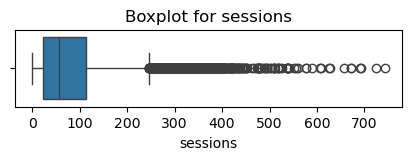

In [6]:
#Visulization
#Examining the spread and distribution of important variables using Boxplots and Histograms
#1. session
#Box-plot
plt.figure(figsize=(5,1))
sns.boxplot(data = df, x = 'sessions')
plt.title("Boxplot for sessions")

Text(0.5, 1.0, 'Histogram for sessions')

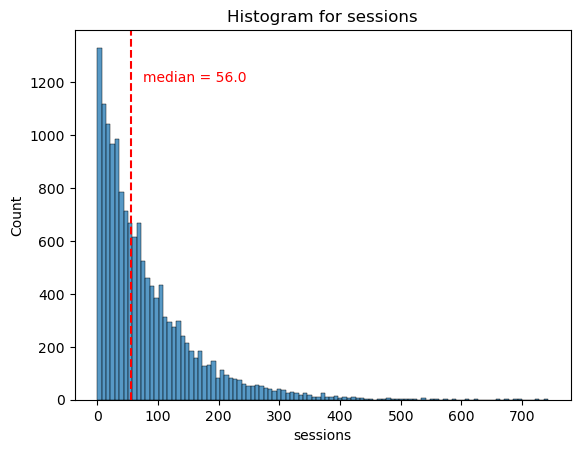

In [7]:
#Histogram
sns.histplot(data = df, x = 'sessions')
median = df['sessions'].median()
plt.axvline(median, color = 'red', linestyle='--')
plt.text(75,1200, f'median = {median}', color='red')
plt.title('Histogram for sessions')

The `sessions` variable is a right-skewed distribution with half of the observations having 56 or fewer sessions. However, as indicated by the boxplot, some users have more than 700.

Text(0.5, 1.0, 'Boxplot for drives')

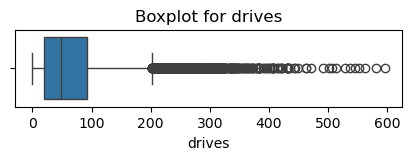

In [8]:
#2. drives
#Boxplot
plt.figure(figsize=(5,1))
sns.boxplot(x = df['drives'])
plt.title('Boxplot for drives')

Text(0.5, 1.0, 'Histogram for drives')

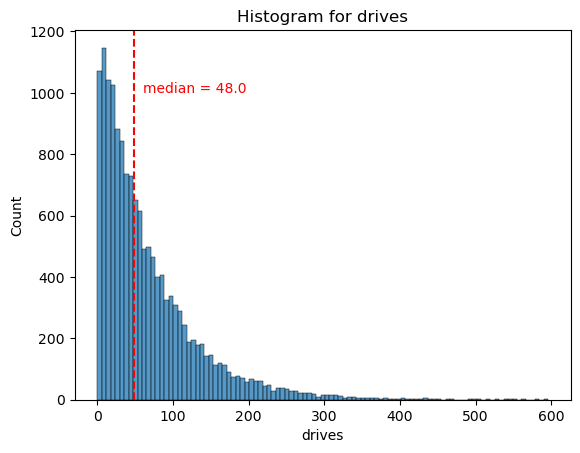

In [9]:
#Histogram
sns.histplot(x = df['drives'])
median = df['drives'].median()
plt.axvline(median, color = 'red', linestyle='--')
plt.text(60,1000, f'median = {median}', color = 'red')
plt.title('Histogram for drives')

The `drives` information follows a distribution similar to the `sessions` variable. It is right-skewed, approximately log-normal, with a median of 48. However, some drivers had over 400 drives in the last month.

Text(0.5, 1.0, 'Boxplot for total sessions')

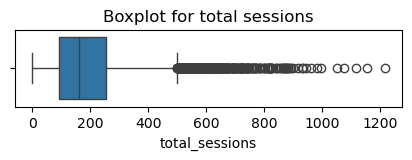

In [10]:
#3. total_sessions
#Boxplot
plt.figure(figsize=(5,1))
sns.boxplot(x = df['total_sessions'])
plt.title("Boxplot for total sessions")

In [11]:
#Helper function to plot histograms based on the
#format of the `sessions` histogram
def histogrammer(column_str, median_text=True, **kwargs):    #**kwargs = any keyword arguments
                                                             #from the sns.histplot() function
    median=round(df[column_str].median(), 1)
    plt.figure(figsize=(5,3))
    ax = sns.histplot(x=df[column_str], **kwargs)            #Plot the histogram
    plt.axvline(median, color='red', linestyle='--')         #Plot the median line
    if median_text==True:                                    #Add median text unless set to False
        ax.text(0.25, 0.85, f'median={median}', color='red',
            ha='left', va='top', transform=ax.transAxes)
    else:
        print('Median:', median)
    plt.title(f'Histogram for {column_str}');

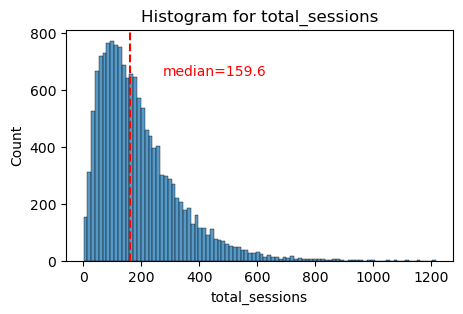

In [12]:
#Histogram
histogrammer('total_sessions')

The `total_sessions` is a right-skewed distribution. The median total number of sessions is 159.6. This is interesting information because, if the median number of sessions in the last month was 48 and the median total sessions was ~160, then it seems that a large proportion of a user's total drives might have taken place in the last month. This is something you can examine more closely later.

Text(0.5, 1.0, 'Boxplot for n_days_after_onboarding')

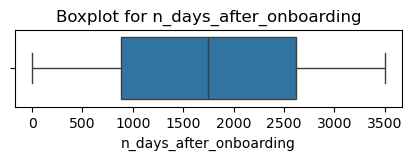

In [13]:
#4. n_days_after_onboarding
#Boxplot
plt.figure(figsize=(5,1))
sns.boxplot(x = df['n_days_after_onboarding'])
plt.title('Boxplot for n_days_after_onboarding')

Median: 1741.0


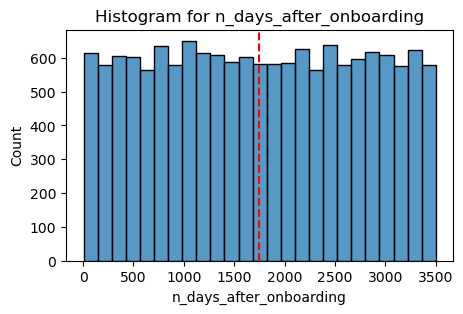

In [14]:
#Histogram
histogrammer('n_days_after_onboarding', median_text=False)

The total user tenure (i.e., number of days since
onboarding) is a uniform distribution with values ranging from near-zero to \~3,500 (\~9.5 years).

Text(0.5, 1.0, 'Boxplot for driven_km_drives')

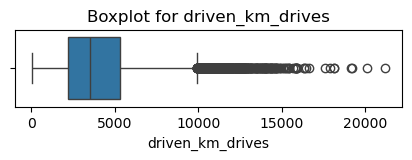

In [15]:
#5. drives_km_drives
#Box plot
plt.figure(figsize=(5,1))
sns.boxplot(x = df['driven_km_drives'])
plt.title('Boxplot for driven_km_drives')

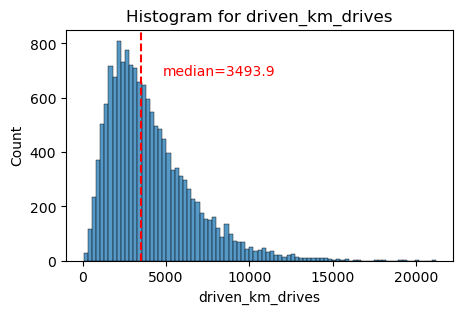

In [16]:
#Histogram
histogrammer('driven_km_drives')

The number of drives driven in the last month per user is a right-skewed distribution with half the users driving under 3,495 kilometers. As you discovered in the analysis from the previous course, the users in this dataset drive _a lot_. The longest distance driven in the month was over half the circumferene of the earth.

Text(0.5, 1.0, 'Boxplot for duration_minutes_drives')

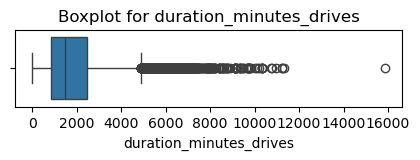

In [17]:
#6. duration_minutes_drives
#Box plot
plt.figure(figsize=(5,1))
sns.boxplot(x = df['duration_minutes_drives'])
plt.title('Boxplot for duration_minutes_drives')

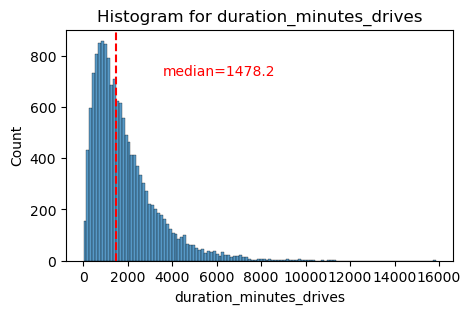

In [18]:
#Histogram
histogrammer('duration_minutes_drives')

The `duration_minutes_drives` variable has a heavily skewed right tail. Half of the users drove less than \~1,478 minutes (\~25 hours), but some users clocked over 250 hours over the month.

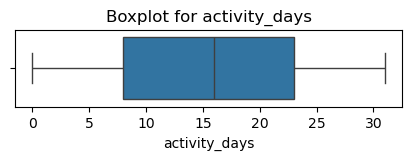

In [19]:
#7. activity_days
#Box plot
def boxplotter(column_str, **kwargs):
    plt.figure(figsize=(5,1))
    sns.boxplot(x = df[column_str])
    plt.title(f'Boxplot for {column_str}')

boxplotter('activity_days')

Median: 16.0


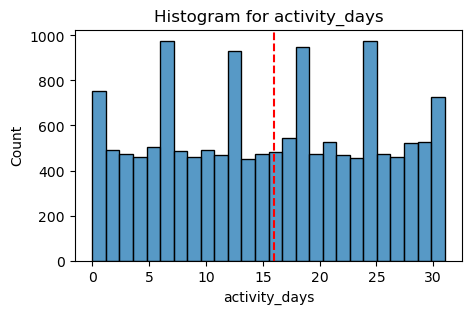

In [20]:
#Histogram
histogrammer('activity_days', median_text=False)

Within the last month, users opened the app a median of 16 times. The box plot reveals a centered distribution. The histogram shows a nearly uniform distribution of ~500 people opening the app on each count of days. However, there are ~250 people who didn't open the app at all and ~250 people who opened the app every day of the month.

This distribution is noteworthy because it does not mirror the `sessions` distribution, which you might think would be closely correlated with `activity_days`.

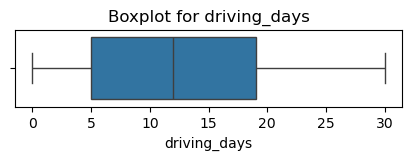

In [21]:
#8. driving_days
boxplotter('driving_days')

Median: 12.0


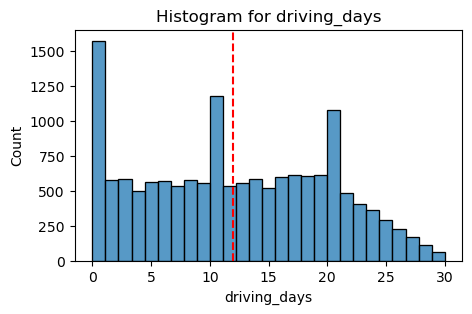

In [22]:
#Histogram
histogrammer('driving_days', median_text=False)

The number of days users drove each month is almost uniform, and it largely correlates with the number of days they opened the app that month, except the `driving_days` distribution tails off on the right.

However, there were almost twice as many users (\~1,000 vs. \~550) who did not drive at all during the month. This might seem counterintuitive when considered together with the information from `activity_days`. That variable had \~500 users opening the app on each of most of the day counts, but there were only \~250 users who did not open the app at all during the month and ~250 users who opened the app every day.

In [23]:
#function for piechart
def pieplotter(column_str):
    fig = plt.figure(figsize=(3,3))
    data=df[column_str].value_counts()
    plt.pie(data, labels=[f'{data.index[0]}:{data.values[0]}',
                      f'{data.index[1]}:{data.values[1]}'], 
                      autopct='%1.1f%%')

Text(0.5, 1.0, 'Users by device')

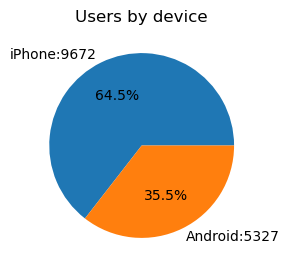

In [24]:
#9. device
#Pie chart
pieplotter('device')
plt.title('Users by device')

There are nearly twice as many iPhone users as Android users represented in this data.

Text(0.5, 1.0, 'Retained vs. Churned users')

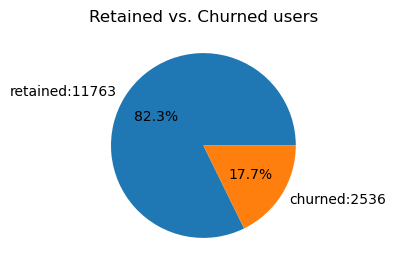

In [25]:
#10. label
#Pie chart
pieplotter('label')
plt.title('Retained vs. Churned users')

Less than 18% of the users churned.

`driving_days` and `activity_days` represent counts of days over a month and they're also closely related, you can plot them together on a single histogram.

Text(0.5, 1.0, 'driving_days v/s activity_days')

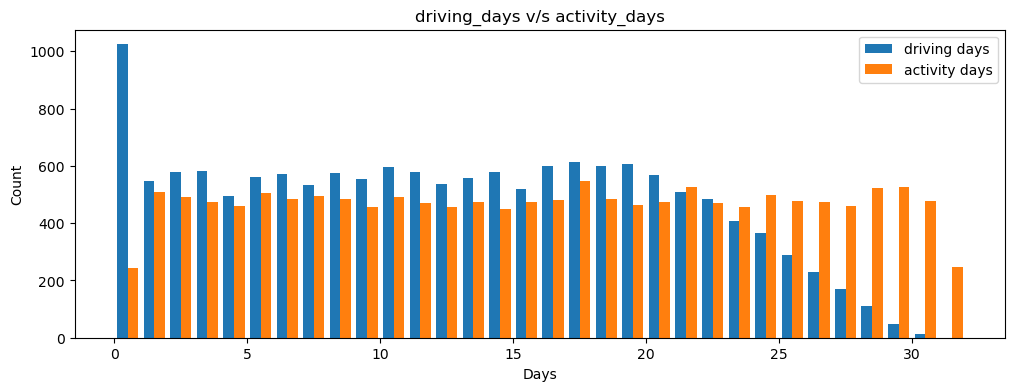

In [26]:
#driving_days vs. activity_days
# Histogram
plt.figure(figsize=(12,4))
label=['driving days', 'activity days']
plt.hist([df['driving_days'], df['activity_days']],
         bins = range(0, 33),
         label=label)
plt.xlabel("Days")
plt.ylabel("Count")
plt.legend()
plt.title('driving_days v/s activity_days')

In [27]:
#Max days for driving
df['driving_days'].max()

np.int64(30)

In [28]:
#Max days for activity
df['activity_days'].max()

np.int64(31)

It's possible that not a single user drove all 31 days of the month, it's highly unlikely, considering there are 15,000 people represented in the dataset.

One other way to check the validity of these variables is to plot a simple scatter plot with the x-axis representing one variable and the y-axis representing the other.

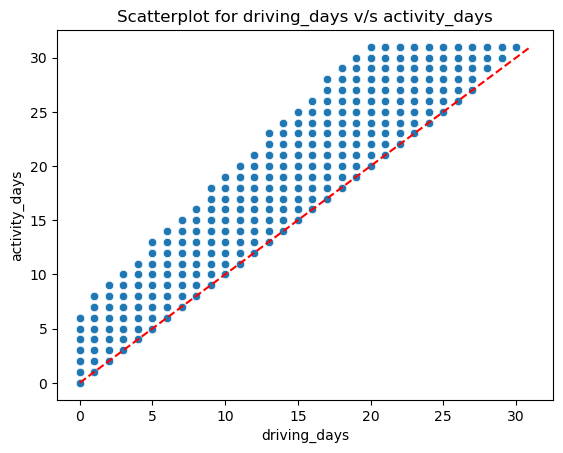

In [29]:
# Scatter plot
sns.scatterplot(x = df['driving_days'], y = df['activity_days'])
plt.title('Scatterplot for driving_days v/s activity_days')
plt.plot([0, 31], [0, 31], color = 'red', linestyle = '--')

Notice that there is a theoretical limit. If you use the app to drive, then by definition it must count as a day-use as well. In other words, you cannot have more drive-days than activity-days. None of the samples in this data violate this rule, which is good.

Text(0.5, 1.0, 'Histogram for Retension by device')

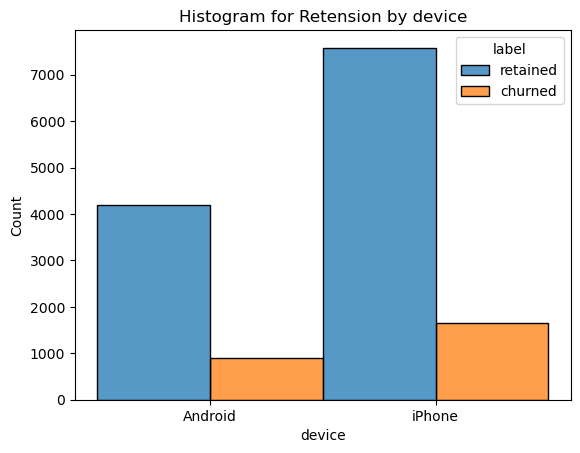

In [30]:
#Retention by device
#Plot a histogram that has four bars, one for each device-label combination.
#To show how many iPhone users were retained/churned and how many Android users were retained/churned.
# Histogram
sns.histplot(data=df,
             x='device',
             hue='label',
             multiple='dodge')
plt.title('Histogram for Retension by device')

The proportion of churned users to retained users is consistent between device types.

In [31]:
#Retention by kilometer driven per driving day
#Create `km_per_driving_day` column
df['km_per_driving_day'] = df['driven_km_drives'] / df['driving_days']
df['km_per_driving_day'].describe()

c:\Users\222817\anaconda3\envs\minimal_ds\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


count    1.499900e+04
mean              inf
std               NaN
min      3.022063e+00
25%      1.672804e+02
50%      3.231459e+02
75%      7.579257e+02
max               inf
Name: km_per_driving_day, dtype: float64

The maximum value is 15,420 kilometers _per drive day_. This is physically impossible. Driving 100 km/hour for 12 hours is 1,200 km. It's unlikely many people averaged more than this each day they drove, so, for now, disregard rows where the distance in this column is greater than 1,200 km.

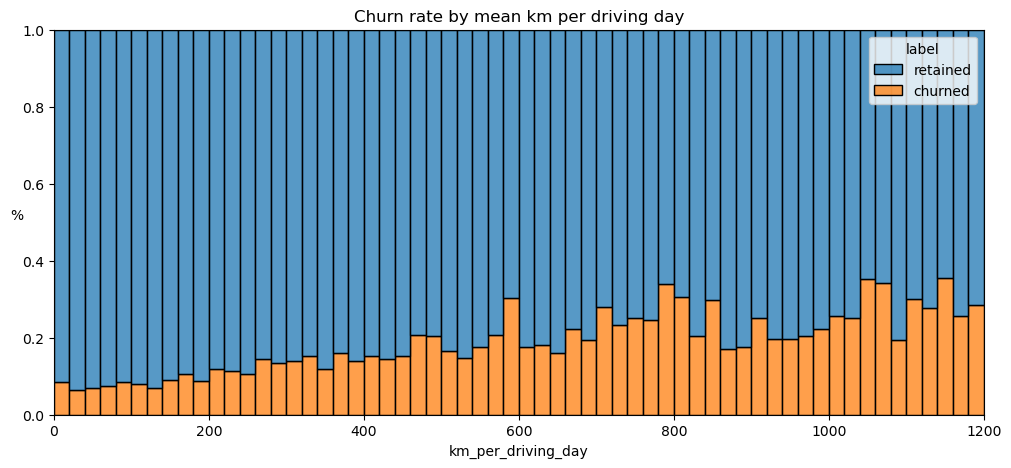

In [32]:
#Histogram
plt.figure(figsize=(12,5))
sns.histplot(data = df,
             x = 'km_per_driving_day',
             bins = range(0,1201,20),
             hue='label',
             multiple='fill')
plt.ylabel('%', rotation=0)
plt.title('Churn rate by mean km per driving day');

The churn rate tends to increase as the mean daily distance driven increases, confirming what was found in the previous course. It would be worth investigating further the reasons for long-distance users to discontinue using the app.

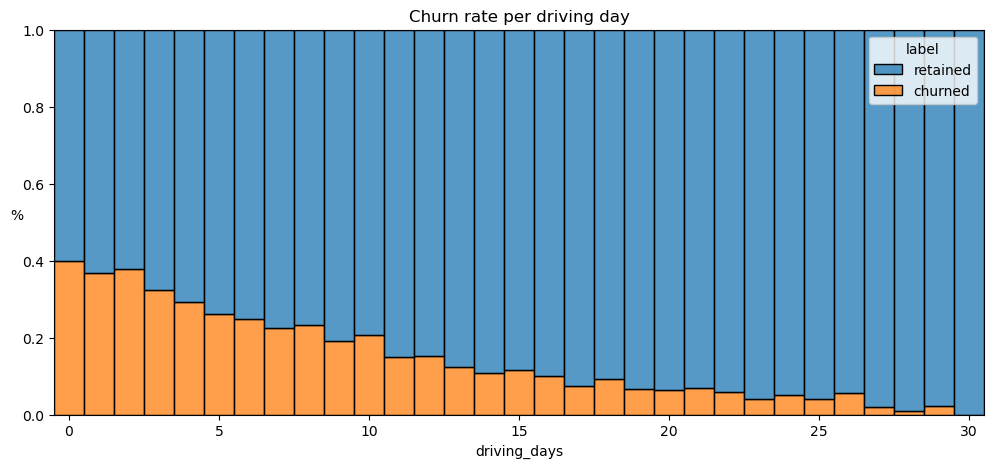

In [33]:
#Histogram for churn rate per driving day
plt.figure(figsize=(12,5))
sns.histplot(data = df,
             x = 'driving_days',
             bins = range(1, 32),
             hue='label',
             multiple='fill',
             discrete=True)
plt.ylabel('%', rotation=0)
plt.title('Churn rate per driving day');

The churn rate is highest for people who didn't use Waze much during the last month. The more times they used the app, the less likely they were to churn. While 40% of the users who didn't use the app at all last month churned, nobody who used the app 30 days churned.

In [34]:
#Create a percent_sessions_in_last_month column
df['percent_sessions_in_last_month'] = df['sessions'] / df['total_sessions']

In [35]:
df['percent_sessions_in_last_month'].median()

np.float64(0.42309702992763176)

Median: 0.4


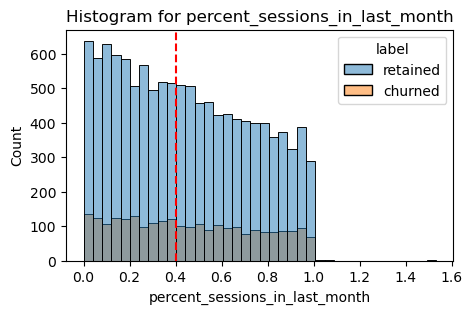

In [36]:
# Histogram
histogrammer('percent_sessions_in_last_month',
             hue=df['label'],
             multiple='layer',
             median_text=False)

In [37]:
#Check the median value of the n_days_after_onboarding column
df['n_days_after_onboarding'].median()

np.float64(1741.0)

Half of the people in the dataset had 40% or more of their sessions in just the last month, yet the overall median time since onboarding is almost five years.

Text(0.5, 1.0, 'Num. days after onboarding for users with >=40% sessions in last month')

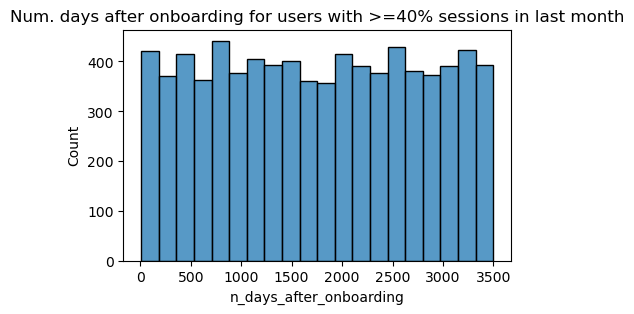

In [38]:
#Histogram
data = df.loc[df['percent_sessions_in_last_month']>=0.4]
plt.figure(figsize=(5,3))
sns.histplot(x=data['n_days_after_onboarding'])
plt.title('Num. days after onboarding for users with >=40% sessions in last month')

The number of days since onboarding for users with 40% or more of their total sessions occurring in just the last month is a uniform distribution. This is very strange. It's worth asking Waze why so many long-time users suddenly used the app so much in the last month.

In [39]:
#Handling Outliers
def outlier_imputer(column_name, percentile):
    # Calculate threshold
    threshold = df[column_name].quantile(percentile)
    # Impute threshold for values > than threshold
    df.loc[df[column_name] > threshold, column_name] = threshold

    print('{:>25} | percentile: {} | threshold: {}'.format(column_name, percentile, threshold))

In [40]:
for column in ['sessions', 'drives', 'total_sessions',
               'driven_km_drives', 'duration_minutes_drives']:
               outlier_imputer(column, 0.95)

                 sessions | percentile: 0.95 | threshold: 243.0
                   drives | percentile: 0.95 | threshold: 201.0
           total_sessions | percentile: 0.95 | threshold: 454.3632037399997
         driven_km_drives | percentile: 0.95 | threshold: 8889.7942356
  duration_minutes_drives | percentile: 0.95 | threshold: 4668.899348999998


In [41]:
df.describe()

c:\Users\222817\anaconda3\envs\minimal_ds\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,ID,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days,km_per_driving_day,percent_sessions_in_last_month
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,1.499900e+04,14999.000000
mean,7499.000000,76.568705,64.058204,184.031320,1749.837789,121.605974,29.672512,3939.632764,1789.647426,15.537102,12.179879,inf,0.449255
std,4329.982679,67.297958,55.306924,118.600463,1008.513876,148.121544,45.394651,2216.041510,1222.705167,9.004655,7.824036,NaN,0.286919
min,0.000000,0.000000,0.000000,0.220211,4.000000,0.000000,0.000000,60.441250,18.282082,0.000000,0.000000,3.022063e+00,0.000000
25%,3749.500000,23.000000,20.000000,90.661156,878.000000,9.000000,0.000000,2212.600607,835.996260,8.000000,5.000000,1.672804e+02,0.196221
50%,7499.000000,56.000000,48.000000,159.568115,1741.000000,71.000000,9.000000,3493.858085,1478.249859,16.000000,12.000000,3.231459e+02,0.423097
75%,11248.500000,112.000000,93.000000,254.192341,2623.500000,178.000000,43.000000,5289.861262,2464.362632,23.000000,19.000000,7.579257e+02,0.687216
max,14998.000000,243.000000,201.000000,454.363204,3500.000000,1236.000000,415.000000,8889.794236,4668.899349,31.000000,30.000000,inf,1.530637


Conclusion


1. Analysis revealed that the overall churn rate is \~17%, and that this rate is consistent between iPhone users and Android users.

2. EDA has revealed that users who drive very long distances on their driving days are _more_ likely to churn, but users who drive more often are _less_ likely to churn. The reason for this discrepancy is an opportunity for further investigation, and it would be something else to ask the Waze data team about.

3. Nearly all the variables were either very right-skewed or uniformly distributed. For the right-skewed distributions, this means that most users had values in the lower end of the range for that variable. For the uniform distributions, this means that users were generally equally likely to have values anywhere within the range for that variable.

4. Less than 18% of users churned, and \~82% were retained.

5. Distance driven per driving day had a positive correlation with user churn. The farther a user drove on each driving day, the more likely they were to churn. On the other hand, number of driving days had a negative correlation with churn. Users who drove more days of the last month were less likely to churn.

6. Users of all tenures from brand new to \~10 years were relatively evenly represented in the data. This is borne out by the histogram for `n_days_after_onboarding`, which reveals a uniform distribution for this variable.